In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [12]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(seq_length, len(data)):
        x = data[i-seq_length:i]
        y = data[i]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # self.fc = nn.Linear(hidden_size, output_size)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )   
    
    def forward(self, x):
        # Inicializa o estado oculto inicial (h0) com zeros
        # Formato: (num_layers, batch_size, hidden_size)
        # Necessário para iniciar a LSTM — pode ser visto como a "memória" inicial da rede
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Inicializa o estado da célula (c0) com zeros
        # Também com shape (num_layers, batch_size, hidden_size)
        # Esse estado armazena informações de longo prazo dentro da LSTM
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Executa a LSTM sobre a sequência de entrada `x`, utilizando os estados iniciais h0 e c0
        # `out` contém todas as saídas da LSTM para cada passo da sequência (shape: [batch_size, seq_len, hidden_size])
        # O segundo retorno (_) seria a tupla (h_n, c_n) com os estados finais, que não estamos usando aqui
        out, _ = self.lstm(x, (h0, c0))

        # Seleciona apenas a saída da última posição da sequência (out[:, -1, :])
        # Essa saída representa a "memória final" da LSTM após ver toda a sequência
        # Em seguida, passa essa saída pela camada linear final (fc) para gerar a predição
        out = self.fc(out[:, -1, :])  # usa apenas a última saída da sequência
        return out

In [14]:
def train_and_eval_lstm(symbol="MSFT", start="2015-01-01", end="2023-01-01", seq_len=15, epochs=30, batch_size=32):
    # Download da série
    df = yf.download(symbol, start=start, end=end, group_by='column')
    if 'Adj Close' in df.columns:
        series = df['Adj Close'].dropna().values
    else:
        series = df['Close'].dropna().values

    # Normalização
    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series.reshape(-1,1)).ravel()

    # Transformar para sequência (supervisionado)
    X, y = create_sequences(series_scaled, seq_len)

    # Split
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Tensores
    X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  # (batch, seq, 1)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

    # DataLoader
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

    # Modelo
    model = LSTMModel()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Treinamento
    loss_history = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss_history[-1]:.6f}")

    # Avaliação
    model.eval()
    with torch.no_grad():
        y_pred_t = model(X_test_t.to(device)).cpu().numpy()
        y_test_np = y_test_t.cpu().numpy()

    # Inverter escala
    y_pred = scaler.inverse_transform(y_pred_t)
    y_test = scaler.inverse_transform(y_test_np)

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"LSTM (PyTorch): RMSE = {rmse:.4f}, MAE = {mae:.4f}")

    # Gráficos
    plt.figure(figsize=(10,5))
    plt.plot(y_test, label='Real')
    plt.plot(y_pred, label='Predito')
    plt.title("Série Real vs Predita (LSTM - PyTorch)")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(loss_history)
    plt.title("Histórico de perda")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot((y_test - y_pred), label="Resíduo")
    plt.title("Erro de predição (resíduo)")
    plt.grid()
    plt.show()

    return model, y_test, y_pred

/var/folders/4g/hm9d3pn57nv1p17qlv8k47mc0000gn/T/ipykernel_37188/466743539.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start, end=end, group_by='column')
[*********************100%***********************]  1 of 1 completed


Epoch 1/30 - Loss: 0.021749
Epoch 2/30 - Loss: 0.005566
Epoch 3/30 - Loss: 0.001048
Epoch 4/30 - Loss: 0.000734
Epoch 5/30 - Loss: 0.000575
Epoch 6/30 - Loss: 0.000540
Epoch 7/30 - Loss: 0.000450
Epoch 8/30 - Loss: 0.000438
Epoch 9/30 - Loss: 0.000422
Epoch 10/30 - Loss: 0.000354
Epoch 11/30 - Loss: 0.000321
Epoch 12/30 - Loss: 0.000314
Epoch 13/30 - Loss: 0.000293
Epoch 14/30 - Loss: 0.000291
Epoch 15/30 - Loss: 0.000254
Epoch 16/30 - Loss: 0.000235
Epoch 17/30 - Loss: 0.000223
Epoch 18/30 - Loss: 0.000218
Epoch 19/30 - Loss: 0.000192
Epoch 20/30 - Loss: 0.000203
Epoch 21/30 - Loss: 0.000259
Epoch 22/30 - Loss: 0.000176
Epoch 23/30 - Loss: 0.000165
Epoch 24/30 - Loss: 0.000164
Epoch 25/30 - Loss: 0.000164
Epoch 26/30 - Loss: 0.000144
Epoch 27/30 - Loss: 0.000144
Epoch 28/30 - Loss: 0.000144
Epoch 29/30 - Loss: 0.000162
Epoch 30/30 - Loss: 0.000140
LSTM (PyTorch): RMSE = 1.0272, MAE = 0.7764


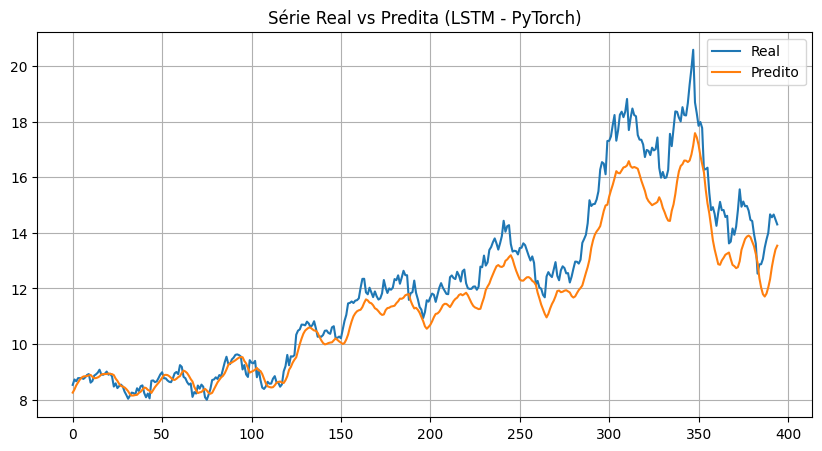

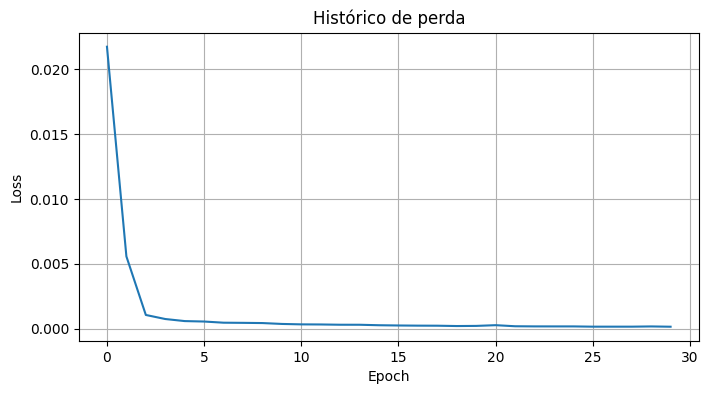

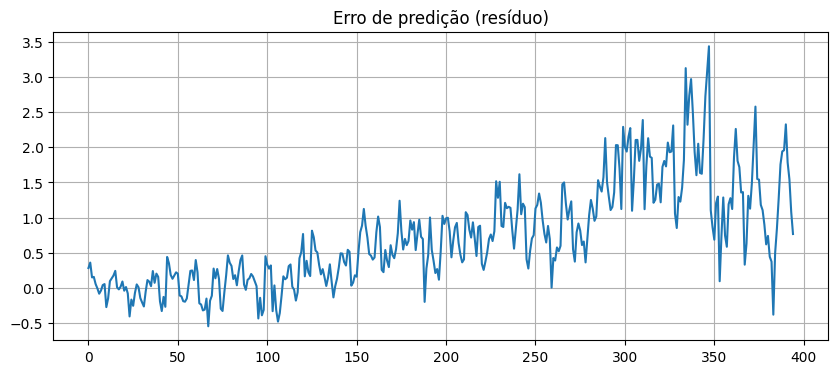

In [15]:
model, y_real, y_pred = train_and_eval_lstm("PETR4.SA", seq_len=15, epochs=30)

# Exercícios

## 1) Alteração da arquitetura

Modifique a arquitetura da LSTM para:
- Adicionar uma segunda camada LSTM
- Incluir uma camada `Dropout(p=0.2)` entre as duas LSTM
- Comparar os resultados com a versão original

> 💡 Lembre-se de atualizar os `hidden_states` e ajustar `num_layers`.

---

## 2) Diferentes tamanhos de janela

Varie o tamanho da janela (`seq_len`) para:
- 10
- 20
- 30

Registre as métricas de erro (RMSE, MAE) e compare os resultados. Qual o impacto de janelas maiores?

---

## 3) Predição multistep

Adapte o modelo LSTM para realizar **previsões de múltiplos passos à frente**, por exemplo:
- Prever os próximos 5 dias de forma sequencial (multi-step forecast)

---

## 4) Variáveis exógenas

Inclua variáveis exógenas na entrada da LSTM. Sugestão:

- `Volume` da ação como segunda feature

> Dica: será necessário transformar a entrada de `(batch, seq_len, 1)` para `(batch, seq_len, 2)`.
